# NTK visualization
This notebook aims to compare the **empirical** Neural Tangent Kernel of different architectures. 

Architectures analysed:
- Base Kernel (just the MLP)
- PINN
- Fourier Features
- SIRENs

plus the **infinite-width** deterministic NTK ($\Theta_\infty$) of the MLP as a reference limit.

We'll consider functions which maps to an unidimensional space to ease the visualisation

## Setup

In [47]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError(f"Cannot find project root from {Path().resolve()}")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

from src.PINNs import PINN, PINNConfig
from src.SIRENs import SIREN, SIRENConfig
from src.spectral_analysis import compute_ntk

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

FIGURES_DIR = Path().resolve() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures -> {FIGURES_DIR}")

ROOT = /Users/marcogalliani/Projects/PINNs-and-spectral-bias
Figures -> /Users/marcogalliani/Projects/PINNs-and-spectral-bias/examples/ntk-nn/figures


In [49]:
class ForcedFirstOrderODE:
    """
    z' = -alpha*z + sum_k A_k sin(2*pi*f_k*t + phi_k)
    """

    def __init__(self, alpha, freqs, amps, phases):
        self.alpha  = alpha
        self.freqs  = list(freqs)
        self.amps   = list(amps)
        self.phases = list(phases)

    def _forcing(self, t, sin_fn):
        return sum(
            A * sin_fn(2 * np.pi * f * t + ph)
            for f, A, ph in zip(self.freqs, self.amps, self.phases)
        )

    def rhs_np(self, t, z):
        return [-self.alpha * z[0] + self._forcing(t, np.sin)]

    def rhs_torch(self, t, z):
        return -self.alpha * z + self._forcing(t, torch.sin)


In [50]:
ode    = ForcedFirstOrderODE(opt.alpha, opt.freqs, opt.amps, opt.phases)
t_eval = np.linspace(0, opt.T, opt.N_POINTS).astype(np.float32)

## Architecture Definitions

In [51]:
# --- Instantiate all architectures at random initialisation ---
mlp     = PINN(PINNConfig(n_vars=1, width=WIDTH, depth=DEPTH)).to(DEVICE)
fourier = PINN(PINNConfig(n_vars=1, width=WIDTH, depth=DEPTH, fourier_freqs=FOURIER_FREQS)).to(DEVICE)
siren   = SIREN(SIRENConfig(n_vars=1, width=WIDTH, depth=DEPTH, omega_0=SIREN_OMEGA)).to(DEVICE)

MODELS = {
    "MLP (Tanh)":  mlp,
    "Fourier MLP": fourier,
    "SIREN":       siren,
}

print(f"{'Architecture':<20} {'Params':>10}")
print("-" * 32)
for name, m in MODELS.items():
    P = sum(p.numel() for p in m.parameters())
    print(f"{name:<20} {P:>10,}")

Architecture             Params
--------------------------------
MLP (Tanh)              264,193
Fourier MLP             272,385
SIREN                   264,193


In [52]:
print("Computing NTK matrices at random initialisation...")
print(f"  Grid: {len(t_eval)} points  |  arch width={WIDTH}, depth={DEPTH}\n")

ntk_matrices    = {}
ntk_eigenvalues = {}
ntk_eigenvectors = {}

for name, model in MODELS.items():
    print(f"  {name}...", end=" ", flush=True)
    K = compute_ntk(model, t_eval, device=DEVICE)
    vals, vecs = np.linalg.eigh(K)
    ntk_matrices[name]     = K
    ntk_eigenvalues[name]  = vals[::-1].copy()
    ntk_eigenvectors[name] = vecs[:, ::-1].copy()
    eff_rank = int((vals.sum() ** 2) / (vals ** 2).sum())   # participation ratio
    print(f"λ_max={vals[-1]:.2e}  λ_min={vals[vals > 0].min():.2e}  eff_rank≈{eff_rank}")

# PINN NTK: same MLP backbone but Jacobian is ∂R/∂θ instead of ∂f/∂θ
print(f"  PINN NTK (K_ff)...", end=" ", flush=True)
K_pinn = mlp.ntk(t_eval, ode.rhs_torch, device=DEVICE)
vals_p, vecs_p = np.linalg.eigh(K_pinn)
ntk_matrices["PINN NTK"]     = K_pinn
ntk_eigenvalues["PINN NTK"]  = vals_p[::-1].copy()
ntk_eigenvectors["PINN NTK"] = vecs_p[:, ::-1].copy()
eff_rank_p = int((vals_p.sum() ** 2) / (vals_p ** 2).sum())
print(f"λ_max={vals_p[-1]:.2e}  λ_min={vals_p[vals_p > 0].min():.2e}  eff_rank≈{eff_rank_p}")

ARCH_NAMES = list(ntk_matrices.keys())
PALETTE    = dict(zip(ARCH_NAMES, sns.color_palette("tab10", len(ARCH_NAMES))))

Computing NTK matrices at random initialisation...
  Grid: 200 points  |  arch width=512, depth=3

  MLP (Tanh)... λ_max=1.91e+04  λ_min=1.73e-05  eff_rank≈1
  Fourier MLP... λ_max=2.40e+03  λ_min=9.96e-04  eff_rank≈10
  SIREN... λ_max=4.11e+04  λ_min=5.85e-05  eff_rank≈1
  PINN NTK (K_ff)... λ_max=3.49e+04  λ_min=6.87e-05  eff_rank≈1


## Infinite-width limit (deterministic NTK)

The kernels above are *empirical* — single random draws at finite width. As width $\to\infty$ the
(standard-parametrisation) NTK of the plain MLP converges to a **deterministic** kernel $\Theta_\infty$
given by the NNGP/NTK recursion (Jacot et al. 2018):

$$\Sigma^{(1)} = \sigma_w^2\,\tfrac{x\cdot x'}{d} + \sigma_b^2,\quad
\Sigma^{(l+1)} = \sigma_w^2\,\mathbb{E}[\sigma(u)\sigma(v)] + \sigma_b^2,\quad
\Theta^{(l+1)} = \Sigma^{(l+1)} + \Theta^{(l)}\,\sigma_w^2\,\mathbb{E}[\sigma'(u)\sigma'(v)].$$

For tanh the Gaussian expectations have no closed form, so we evaluate them by 2-D Gauss–Hermite
quadrature. We add $\Theta_\infty$ next to the empirical MLP as a **reference**: the finite MLP NTK is
already within a few percent of it (correlation form), so the near-rank-1 structure and low-frequency
eigenvectors you see for the MLP are properties of the *limit*, not of finite width.

> NTK magnitude is parametrisation-dependent; we rescale $\Theta_\infty$ so its top eigenvalue matches the
> empirical MLP for the spectrum overlay (heatmaps and slices are normalised anyway).

In [53]:
# ── Infinite-width NTK via the NNGP/NTK recursion (tanh, Gauss–Hermite) ────────
SW2_INF, SB2_INF = 1.0, 0.2          # chosen to match this notebook's default-init MLP
_GH = 20
_ghx, _ghw = np.polynomial.hermite.hermgauss(_GH)
_ghx = np.sqrt(2.0) * _ghx
_ghw = _ghw / np.sqrt(np.pi)

def _tanh_expectations(var, Cov):
    """E[σ(u)σ(v)] and E[σ'(u)σ'(v)] for (u,v)~N(0,Λ), elementwise over a grid (tanh)."""
    sd = np.sqrt(np.clip(var, 1e-30, None))
    rho = np.clip(Cov / np.outer(sd, sd), -1.0, 1.0)
    comp = np.sqrt(np.clip(1.0 - rho ** 2, 0.0, None))
    Ess = np.zeros_like(Cov); Edd = np.zeros_like(Cov)
    for p in range(_GH):
        u = sd[:, None] * _ghx[p]; tu = np.tanh(u); du = 1.0 - tu ** 2
        for q in range(_GH):
            v = sd[None, :] * (rho * _ghx[p] + comp * _ghx[q]); w = _ghw[p] * _ghw[q]
            Ess += w * tu * np.tanh(v)
            Edd += w * du * (1.0 - np.tanh(v) ** 2)
    return (Ess + Ess.T) / 2.0, (Edd + Edd.T) / 2.0

def infinite_width_ntk(t, depth, sigma_w2=1.0, sigma_b2=0.2):
    """Deterministic NTK Θ_∞ of an infinitely wide tanh MLP with `depth` weight layers."""
    X = np.asarray(t, dtype=float).reshape(-1, 1)
    Sigma = sigma_w2 * (X @ X.T) + sigma_b2          # Σ^(1)
    Theta = Sigma.copy()                              # Θ^(1)
    for _ in range(depth - 1):
        Ess, Edd = _tanh_expectations(np.diag(Sigma).copy(), Sigma)
        Sigma = sigma_w2 * Ess + sigma_b2            # Σ^(l+1)
        Theta = Sigma + Theta * (sigma_w2 * Edd)     # Θ^(l+1)
    return Theta

def _corr(K):
    d = np.sqrt(np.diag(K).clip(0)); d = np.where(d == 0, 1.0, d); return K / np.outer(d, d)

INF_NAME = "MLP ∞-width (Θ∞)"
print("Computing infinite-width NTK (tanh, depth %d)..." % DEPTH, flush=True)
K_inf_raw = infinite_width_ntk(t_eval, DEPTH, SW2_INF, SB2_INF)
# rescale so λ_max matches the empirical MLP (NTK scale is parametrisation-dependent)
lam_inf_max = np.linalg.eigvalsh(K_inf_raw)[-1]
K_inf = K_inf_raw * (ntk_eigenvalues["MLP (Tanh)"][0] / lam_inf_max)

vals_inf, vecs_inf = np.linalg.eigh(K_inf)
ntk_matrices[INF_NAME]     = K_inf
ntk_eigenvalues[INF_NAME]  = vals_inf[::-1].copy()
ntk_eigenvectors[INF_NAME] = vecs_inf[:, ::-1].copy()

rel = (np.linalg.norm(_corr(K_inf) - _corr(ntk_matrices["MLP (Tanh)"]))
       / np.linalg.norm(_corr(ntk_matrices["MLP (Tanh)"])))
eff_rank_inf = int((vals_inf.sum() ** 2) / (vals_inf ** 2).sum())
print(f"  Θ∞  eff_rank≈{eff_rank_inf}   |  corr-distance to finite MLP NTK = {rel:.3f}")

# Re-order so Θ∞ sits next to the empirical MLP, then refresh the shared lookups
_order = ["MLP (Tanh)", INF_NAME, "Fourier MLP", "SIREN", "PINN NTK"]
ntk_matrices     = {k: ntk_matrices[k]     for k in _order}
ntk_eigenvalues  = {k: ntk_eigenvalues[k]  for k in _order}
ntk_eigenvectors = {k: ntk_eigenvectors[k] for k in _order}
ARCH_NAMES = list(ntk_matrices.keys())
PALETTE    = dict(zip(ARCH_NAMES, sns.color_palette("tab10", len(ARCH_NAMES))))

Computing infinite-width NTK (tanh, depth 3)...
  Θ∞  eff_rank≈1   |  corr-distance to finite MLP NTK = 0.031


## Visualizations

### NTK Heatmaps

`K[i, j]` measures how correlated the gradient directions are at inputs `t_i` and `t_j`.
A kernel concentrated along the diagonal indicates localised representations; off-diagonal mass
indicates that learning at one point affects many others.
Each matrix is normalised by its maximum value for comparability.

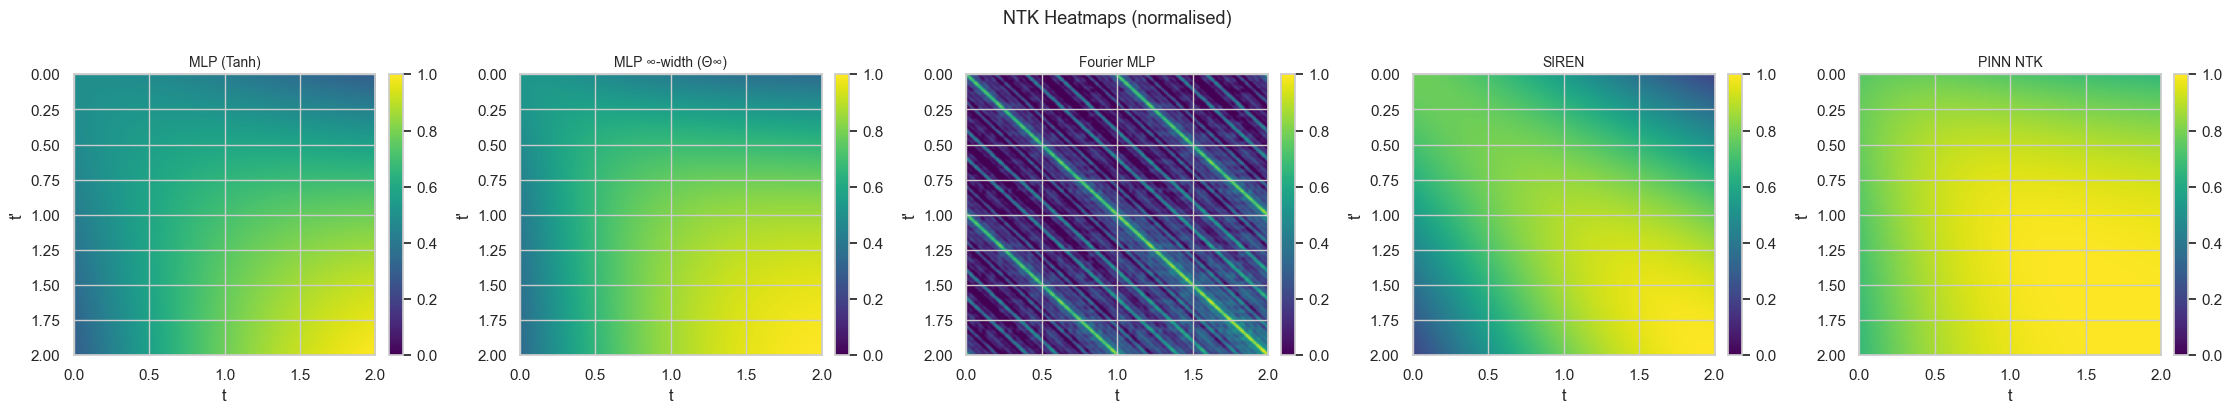

In [54]:
N = len(ARCH_NAMES)
fig, axes = plt.subplots(1, N, figsize=(4.5 * N, 4.2))
fig.suptitle("NTK Heatmaps (normalised)", fontsize=13)

for ax, name in zip(axes, ARCH_NAMES):
    K     = ntk_matrices[name]
    K_vis = K / K.max()
    im = ax.imshow(
        K_vis, cmap="viridis", aspect="auto",
        extent=[t_eval[0], t_eval[-1], t_eval[-1], t_eval[0]],
        vmin=0, vmax=1,
    )
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("t")
    ax.set_ylabel("t'")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

### Kernel slice  k(t, t★)

Fixing one argument at a centre point `t★` and varying the other gives a 1-D cross-section of
the kernel. Its width and shape reveal how far the influence of a single training point spreads:
a narrow peak → localised, independent representations; a broad or oscillatory profile →
long-range correlations across the input domain.
Slices are normalised by `k(t★, t★)` so they all start at 1 and are directly comparable.

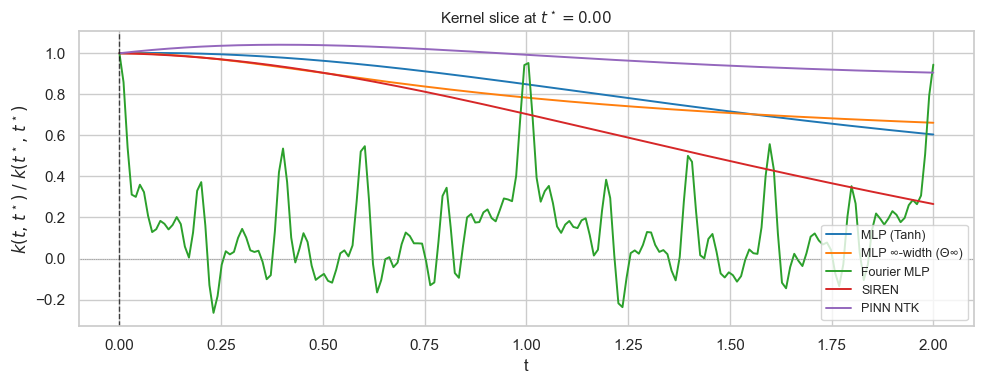

In [55]:
T_STAR = 0
center_idx   = np.argmin(np.abs(t_eval - T_STAR))
t_star_actual = float(t_eval[center_idx])

fig, ax = plt.subplots(figsize=(10, 4))

for name in ARCH_NAMES:
    K     = ntk_matrices[name]
    slice_ = K[:, center_idx] / K[center_idx, center_idx]   # normalise so k(t★, t★) = 1
    ax.plot(t_eval, slice_, label=name, color=PALETTE[name], linewidth=1.4)

ax.axvline(t_star_actual, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.set_xlabel("t")
ax.set_ylabel(r"$k(t,\, t^\star)\;/\; k(t^\star,\, t^\star)$")
ax.set_title(f"Kernel slice at $t^\\star = {t_star_actual:.2f}$", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_kernel_slice.png", dpi=150, bbox_inches="tight")
plt.show()

### Eigenvalue Spectra

Under gradient-flow, the projection of the error onto the `k`-th NTK eigenvector decays at rate
`exp(-η λ_k t)`. Architectures with a flatter spectrum (slower eigenvalue decay) converge more
uniformly across frequencies — less spectral bias.

The **cumulative trace fraction** shows what share of the total learning speed is concentrated
in the top-k eigenmodes (effective rank).

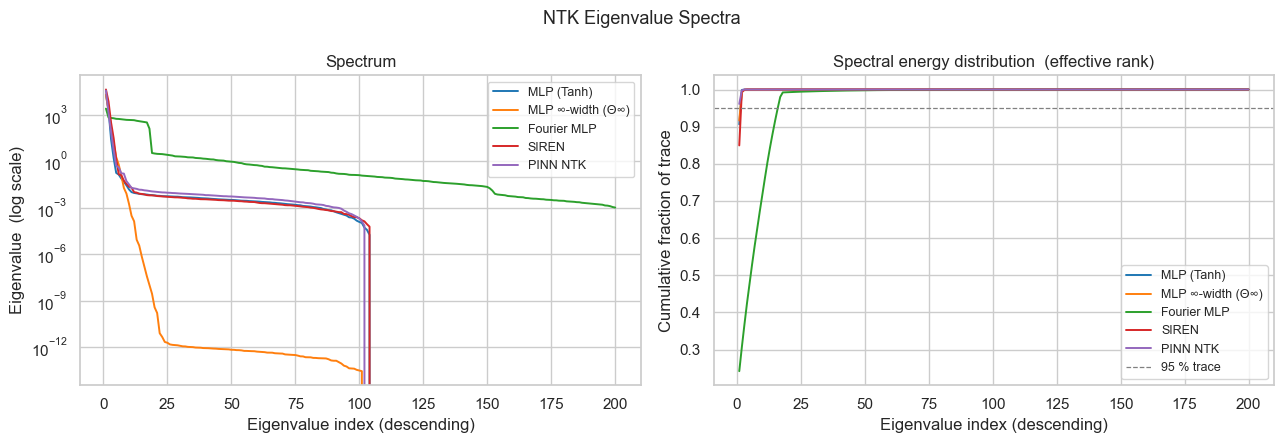

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("NTK Eigenvalue Spectra", fontsize=13)

idx = np.arange(1, len(t_eval) + 1)

ax = axes[0]
for name in ARCH_NAMES:
    vals = ntk_eigenvalues[name]
    ax.semilogy(idx, vals, label=name, color=PALETTE[name], linewidth=1.4)
ax.set_xlabel("Eigenvalue index (descending)")
ax.set_ylabel("Eigenvalue  (log scale)")
ax.set_title("Spectrum")
ax.legend(fontsize=9)

ax = axes[1]
for name in ARCH_NAMES:
    vals = ntk_eigenvalues[name]
    cum  = np.cumsum(vals) / vals.sum()
    ax.plot(idx, cum, label=name, color=PALETTE[name], linewidth=1.4)
ax.axhline(0.95, color="gray", linestyle="--", linewidth=0.9, label="95 % trace")
ax.set_xlabel("Eigenvalue index (descending)")
ax.set_ylabel("Cumulative fraction of trace")
ax.set_title("Spectral energy distribution  (effective rank)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_spectra.png", dpi=150, bbox_inches="tight")
plt.show()

### Leading Eigenvectors

The top eigenvectors are the spatial patterns learned first under gradient flow.
A vanilla MLP (spectral bias) will show smooth low-frequency patterns in v₁, v₂, ...
Fourier and SIREN architectures should show higher-frequency content early in the spectrum.

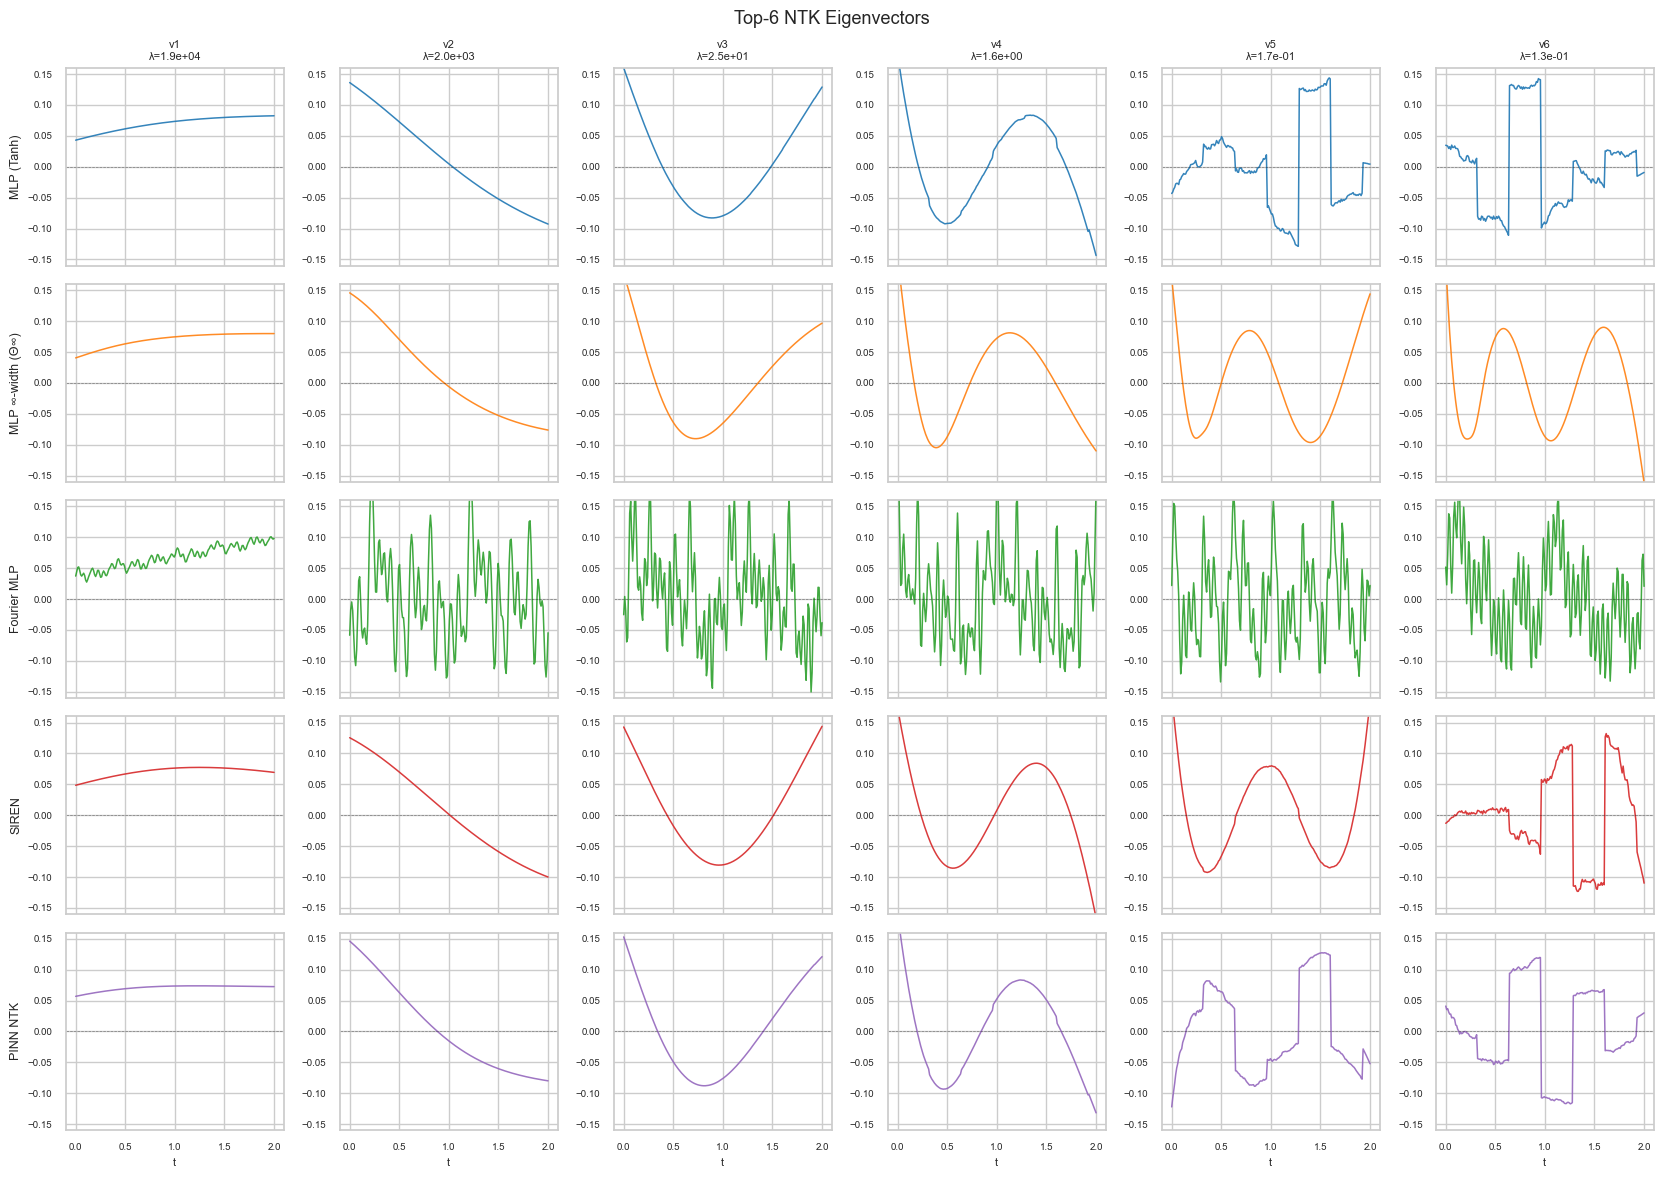

In [57]:
N_VEC = 6
sample_rate = opt.N_POINTS / opt.T

fig, axes = plt.subplots(
    len(ARCH_NAMES), N_VEC,
    figsize=(2.8 * N_VEC, 2.4 * len(ARCH_NAMES)),
    sharex=True,
)
fig.suptitle(f"Top-{N_VEC} NTK Eigenvectors", fontsize=13)

for row, name in enumerate(ARCH_NAMES):
    vecs = ntk_eigenvectors[name]
    vals = ntk_eigenvalues[name]
    col_color = PALETTE[name]

    for col in range(N_VEC):
        ax = axes[row, col]
        v = vecs[:, col]
        v = v * np.sign(v[np.argmax(np.abs(v))])   # fix sign convention
        ax.plot(t_eval, v, linewidth=1.1, color=col_color, alpha=0.9)
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
        ax.set_ylim(-0.16, 0.16)

        if row == 0:
            ax.set_title(f"v{col+1}\nλ={vals[col]:.1e}", fontsize=8)
        if col == 0:
            ax.set_ylabel(name, fontsize=9)
        if row == len(ARCH_NAMES) - 1:
            ax.set_xlabel("t", fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_eigenvectors.png", dpi=150, bbox_inches="tight")
plt.show()

### Dominant frequency of each eigenvector

Reading the NTK eigenvectors in the Fourier domain reveals the frequency content the network
preferentially learns at each rank. Spectral bias predicts that lower-rank (larger λ) eigenvectors
carry lower frequencies for a vanilla MLP.

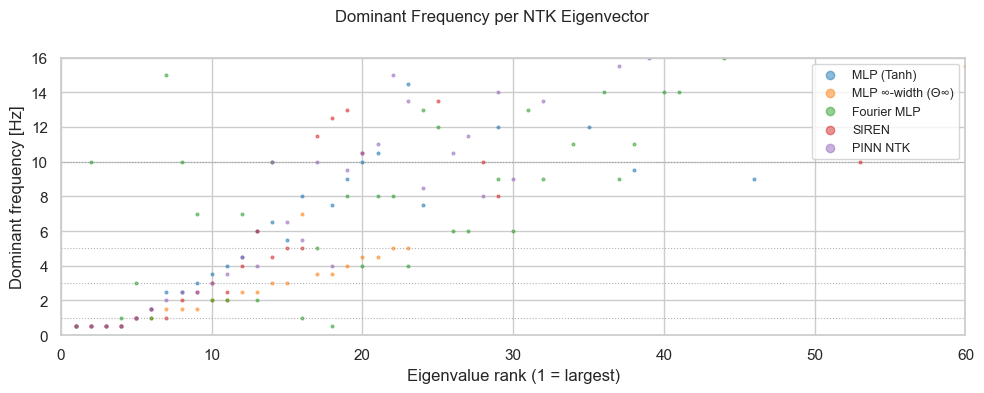

In [58]:
def dominant_freq(vec, sample_rate):
    """Return the frequency [Hz] carrying the most power in vec (skip DC)."""
    freqs = np.fft.rfftfreq(len(vec), d=1.0 / sample_rate)
    spec  = np.abs(np.fft.rfft(vec))
    spec[0] = 0.0          # zero out DC
    return freqs[np.argmax(spec)]

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Dominant Frequency per NTK Eigenvector", fontsize=12)

for name in ARCH_NAMES:
    vecs = ntk_eigenvectors[name]
    dom  = np.array([dominant_freq(vecs[:, k], sample_rate) for k in range(len(t_eval))])
    ax.scatter(
        np.arange(1, len(t_eval) + 1), dom,
        s=4, alpha=0.5, label=name, color=PALETTE[name],
    )

for f in opt.freqs:
    ax.axhline(f, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)

ax.set_xlabel("Eigenvalue rank (1 = largest)")
ax.set_ylabel("Dominant frequency [Hz]")
ax.set_xlim(0, 60)
ax.set_ylim(0, max(opt.freqs) * 1.6)
ax.legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_dominant_freq.png", dpi=150, bbox_inches="tight")
plt.show()

## Physics-Informed NTK vs Base NTK

The **PINN NTK** (`K_ff`) replaces the Jacobian `∂f/∂θ` with the residual Jacobian
`∂R/∂θ = ∂(ẑ' − F)/∂θ`. This incorporates the differential operator into the kernel, so
the eigenvalue structure now reflects how fast each spatial mode of the *ODE residual* converges,
rather than how fast the function values converge.

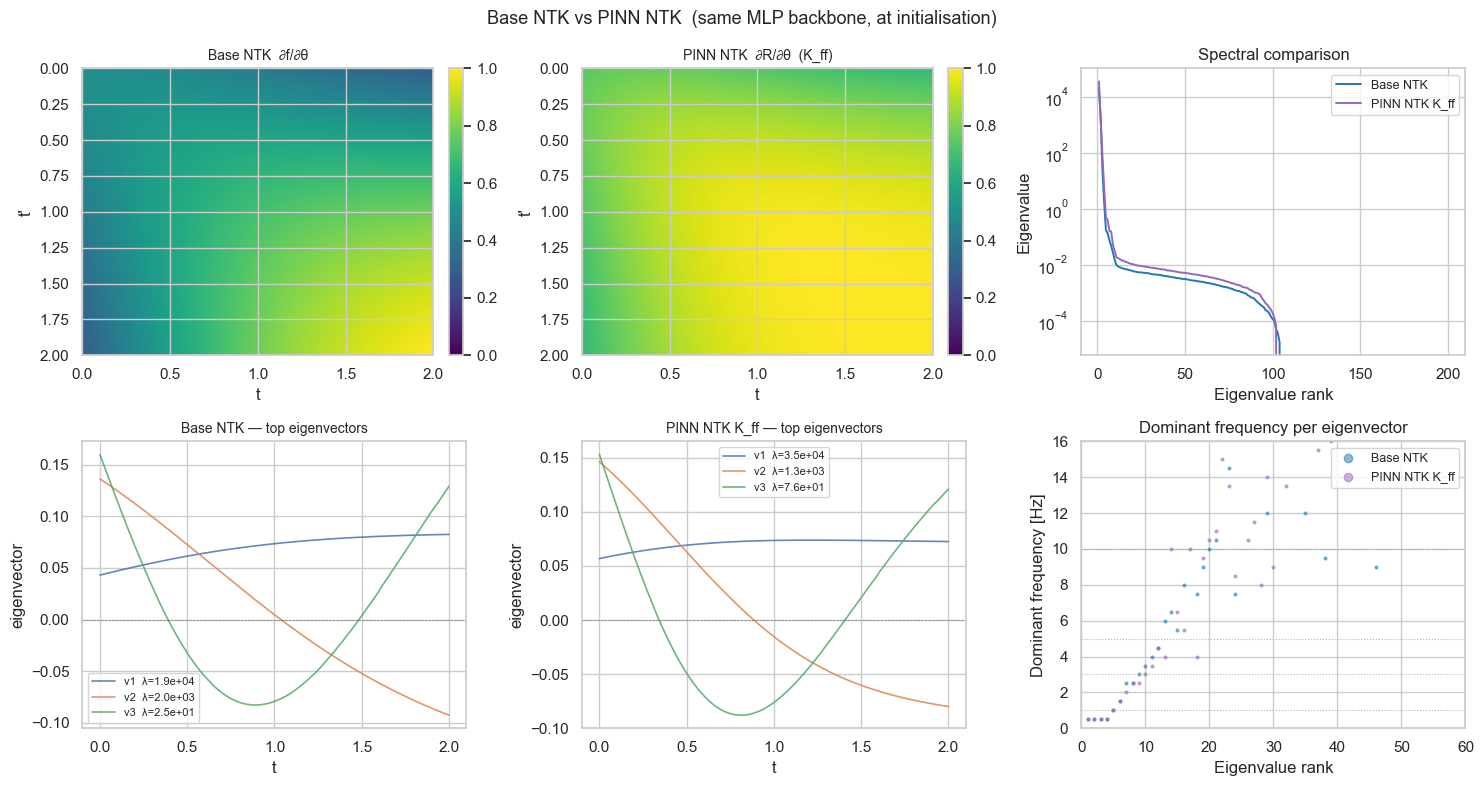

In [59]:
K_base  = ntk_matrices["MLP (Tanh)"]
K_pinn  = ntk_matrices["PINN NTK"]
vals_b  = ntk_eigenvalues["MLP (Tanh)"]
vals_p  = ntk_eigenvalues["PINN NTK"]
vecs_b  = ntk_eigenvectors["MLP (Tanh)"]
vecs_p  = ntk_eigenvectors["PINN NTK"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Base NTK vs PINN NTK  (same MLP backbone, at initialisation)", fontsize=13)

# --- Row 0: heatmaps + spectrum ---
for ax, K, title in [
    (axes[0, 0], K_base / K_base.max(), "Base NTK  ∂f/∂θ"),
    (axes[0, 1], K_pinn / K_pinn.max(), "PINN NTK  ∂R/∂θ  (K_ff)"),
]:
    im = ax.imshow(
        K, cmap="viridis", aspect="auto",
        extent=[t_eval[0], t_eval[-1], t_eval[-1], t_eval[0]],
        vmin=0, vmax=1,
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("t"); ax.set_ylabel("t'")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[0, 2]
ax.semilogy(idx, vals_b, label="Base NTK",     color=PALETTE["MLP (Tanh)"], linewidth=1.4)
ax.semilogy(idx, vals_p, label="PINN NTK K_ff", color=PALETTE["PINN NTK"],  linewidth=1.4)
ax.set_xlabel("Eigenvalue rank")
ax.set_ylabel("Eigenvalue")
ax.set_title("Spectral comparison")
ax.legend(fontsize=9)

# --- Row 1: top-3 eigenvectors side by side ---
N_SHOW = 3
for col, (vecs, vals, color, title) in enumerate([
    (vecs_b, vals_b, PALETTE["MLP (Tanh)"], "Base NTK"),
    (vecs_p, vals_p, PALETTE["PINN NTK"],  "PINN NTK K_ff"),
]):
    ax = axes[1, col]
    for k in range(N_SHOW):
        v = vecs[:, k]
        v = v * np.sign(v[np.argmax(np.abs(v))])
        ax.plot(t_eval, v, linewidth=1.2, alpha=0.85,
                label=f"v{k+1}  λ={vals[k]:.1e}")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
    ax.set_xlabel("t"); ax.set_ylabel("eigenvector")
    ax.set_title(f"{title} — top eigenvectors", fontsize=10)
    ax.legend(fontsize=8)

# Dominant-frequency comparison
ax = axes[1, 2]
dom_b = np.array([dominant_freq(vecs_b[:, k], sample_rate) for k in range(len(t_eval))])
dom_p = np.array([dominant_freq(vecs_p[:, k], sample_rate) for k in range(len(t_eval))])
ax.scatter(idx, dom_b, s=4, alpha=0.5, label="Base NTK",     color=PALETTE["MLP (Tanh)"])
ax.scatter(idx, dom_p, s=4, alpha=0.5, label="PINN NTK K_ff", color=PALETTE["PINN NTK"])
for f in opt.freqs:
    ax.axhline(f, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Eigenvalue rank")
ax.set_ylabel("Dominant frequency [Hz]")
ax.set_title("Dominant frequency per eigenvector")
ax.set_xlim(0, 60); ax.set_ylim(0, max(opt.freqs) * 1.6)
ax.legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pinn_vs_base_ntk.png", dpi=150, bbox_inches="tight")
plt.show()

## Infinite-width kernels for every architecture

We computed $\Theta_\infty$ for the plain MLP above. The same machinery extends to the others — each
architecture changes exactly **one** stage of the NNGP/NTK recursion:

- **Fourier MLP** — the embedding is a *fixed* map, so seed the recursion with the embedding Gram
  $\gamma(t)\cdot\gamma(t') = \sum_k\cos\!\big(2\pi f_k(t-t')\big) + t\,t'$ instead of the raw dot product, then
  run the same tanh recursion. (Already multi-mode → high effective rank, before the MLP even acts.)
- **SIREN** — replace tanh by sin: the Gaussian expectations are closed-form,
  $\mathbb{E}[\sin u\,\sin v]=e^{-(a+b)/2}\sinh c$ and $\mathbb{E}[\sin' u\,\sin' v]=e^{-(a+b)/2}\cosh c$.
  The $\omega_0=30$ scaling makes the first-layer variance $O(\omega_0^2)$, so we use the numerically-stable
  form — Gauss–Hermite quadrature is unreliable at that scale (it mis-integrates the rapid oscillations).
- **PINN** — apply the linear operator to the backbone limit:
  $\Theta_{\mathrm{PINN}}^{\infty} = (\partial_t+\alpha)(\partial_{t'}+\alpha)\,\Theta_\infty$.

These are the deterministic limits the finite kernels approach. We report the correlation-form distance to
each empirical kernel below; the $\omega_0=30$ SIREN converges slowly with width, so its match is the loosest
(but the effective rank and localisation length are right).

In [60]:
# ── Infinite-width kernels for Fourier, SIREN, PINN (reuses _tanh_expectations) ─
def _sincos_expectations(var, Cov):
    """E[sin u sin v]=e^{-(a+b)/2}sinh(c) and E[sin'u sin'v]=E[cos u cos v]=e^{-(a+b)/2}cosh(c),
    in overflow-safe form (SIREN pre-activation variances are O(ω₀²))."""
    a = var[:, None]; b = var[None, :]; c = Cov
    half = (a + b) / 2.0
    Ess = 0.5 * (np.exp(c - half) - np.exp(-c - half))
    Ecc = 0.5 * (np.exp(c - half) + np.exp(-c - half))
    return Ess, Ecc

def _iw_tanh_from_base(Sigma1, depth, sigma_w2):
    """tanh NNGP/NTK recursion seeded from a given first-layer covariance Σ^(1)."""
    Sigma = Sigma1.copy(); Theta = Sigma.copy()
    for _ in range(depth - 1):
        Ess, Edd = _tanh_expectations(np.diag(Sigma).copy(), Sigma)
        Sigma = sigma_w2 * Ess
        Theta = Sigma + Theta * (sigma_w2 * Edd)
    return Theta

def infinite_width_fourier(t, freqs, depth, sigma_w2, sigma_b2):
    """Θ_∞ of a tanh MLP on a fixed Fourier embedding (base = embedding Gram)."""
    tt = np.asarray(t, float)
    cols = [np.sin(2*np.pi*f*tt) for f in freqs] + [np.cos(2*np.pi*f*tt) for f in freqs] + [tt]
    G = np.stack(cols, 1)
    Sigma1 = sigma_w2 * (G @ G.T) / G.shape[1] + sigma_b2
    return _iw_tanh_from_base(Sigma1, depth, sigma_w2)

def infinite_width_siren(t, depth, scale1, offset1, gw_hidden=2.0):
    """Θ_∞ of a SIREN (sin activation, closed-form expectations). scale1/offset1 are
    the effective first-layer pre-activation variance constants (∝ ω₀²·Var(W),Var(b))."""
    X = np.asarray(t, float).reshape(-1, 1)
    Lam = scale1 * (X @ X.T) + offset1
    Theta = Lam.copy()
    for _ in range(depth - 2):                              # hidden sin layers
        Ess, Ecc = _sincos_expectations(np.diag(Lam).copy(), Lam)
        Lam = gw_hidden * Ess
        Theta = Lam + Theta * (gw_hidden * Ecc)
    Ess, _ = _sincos_expectations(np.diag(Lam).copy(), Lam)  # linear readout
    return Ess + Theta

def apply_ode_operator(Theta, t, alpha):
    """(∂_t+α)(∂_{t'}+α) Θ by finite differences (the PINN ∞-width kernel)."""
    h = t[1] - t[0]
    d_t = np.gradient(Theta, h, axis=0); d_tp = np.gradient(Theta, h, axis=1)
    d_ttp = np.gradient(d_tp, h, axis=0)
    return d_ttp + alpha * d_t + alpha * d_tp + alpha ** 2 * Theta

# effective init constants (chosen to match this notebook's finite kernels)
SW2_F, SB2_F = 0.5, 0.05            # Fourier tanh layers
S1_S, S0_S   = 600.0, 300.0         # SIREN effective first-layer scale (≈ 2·ω₀²/3, ω₀=30)

K_inf_mlp     = ntk_matrices["MLP ∞-width (Θ∞)"]                       # from earlier cell
K_inf_fourier = infinite_width_fourier(t_eval, FOURIER_FREQS, DEPTH, SW2_F, SB2_F)
K_inf_siren   = infinite_width_siren(t_eval, DEPTH, S1_S, S0_S)
K_inf_pinn    = apply_ode_operator(K_inf_mlp, t_eval, opt.alpha)

# pair each empirical kernel with its infinite-width limit
INF_PAIRS = {
    "MLP (Tanh)":  (ntk_matrices["MLP (Tanh)"],  K_inf_mlp),
    "Fourier MLP": (ntk_matrices["Fourier MLP"], K_inf_fourier),
    "SIREN":       (ntk_matrices["SIREN"],       K_inf_siren),
    "PINN NTK":    (ntk_matrices["PINN NTK"],     K_inf_pinn),
}

def _eff_rank(K):
    w = np.linalg.eigvalsh(_corr(K)); w = w[w > 1e-12]; return w.sum() ** 2 / (w ** 2).sum()

sl = slice(2, -2)   # trim finite-difference edges (matters only for PINN)
print(f"{'architecture':<13} {'corr-dist':>9} {'eff_rank emp':>13} {'eff_rank Θ∞':>12}")
print("-" * 50)
for name, (K_emp, K_inf) in INF_PAIRS.items():
    cd = (np.linalg.norm(_corr(K_inf)[sl, sl] - _corr(K_emp)[sl, sl])
          / np.linalg.norm(_corr(K_emp)[sl, sl]))
    print(f"{name:<13} {cd:>9.3f} {_eff_rank(K_emp):>13.1f} {_eff_rank(K_inf):>12.1f}")

architecture  corr-dist  eff_rank emp  eff_rank Θ∞
--------------------------------------------------
MLP (Tanh)        0.029           1.2          1.2
Fourier MLP       0.145          11.0         11.1
SIREN             0.955           1.4         28.1
PINN NTK          0.058           1.1          1.2


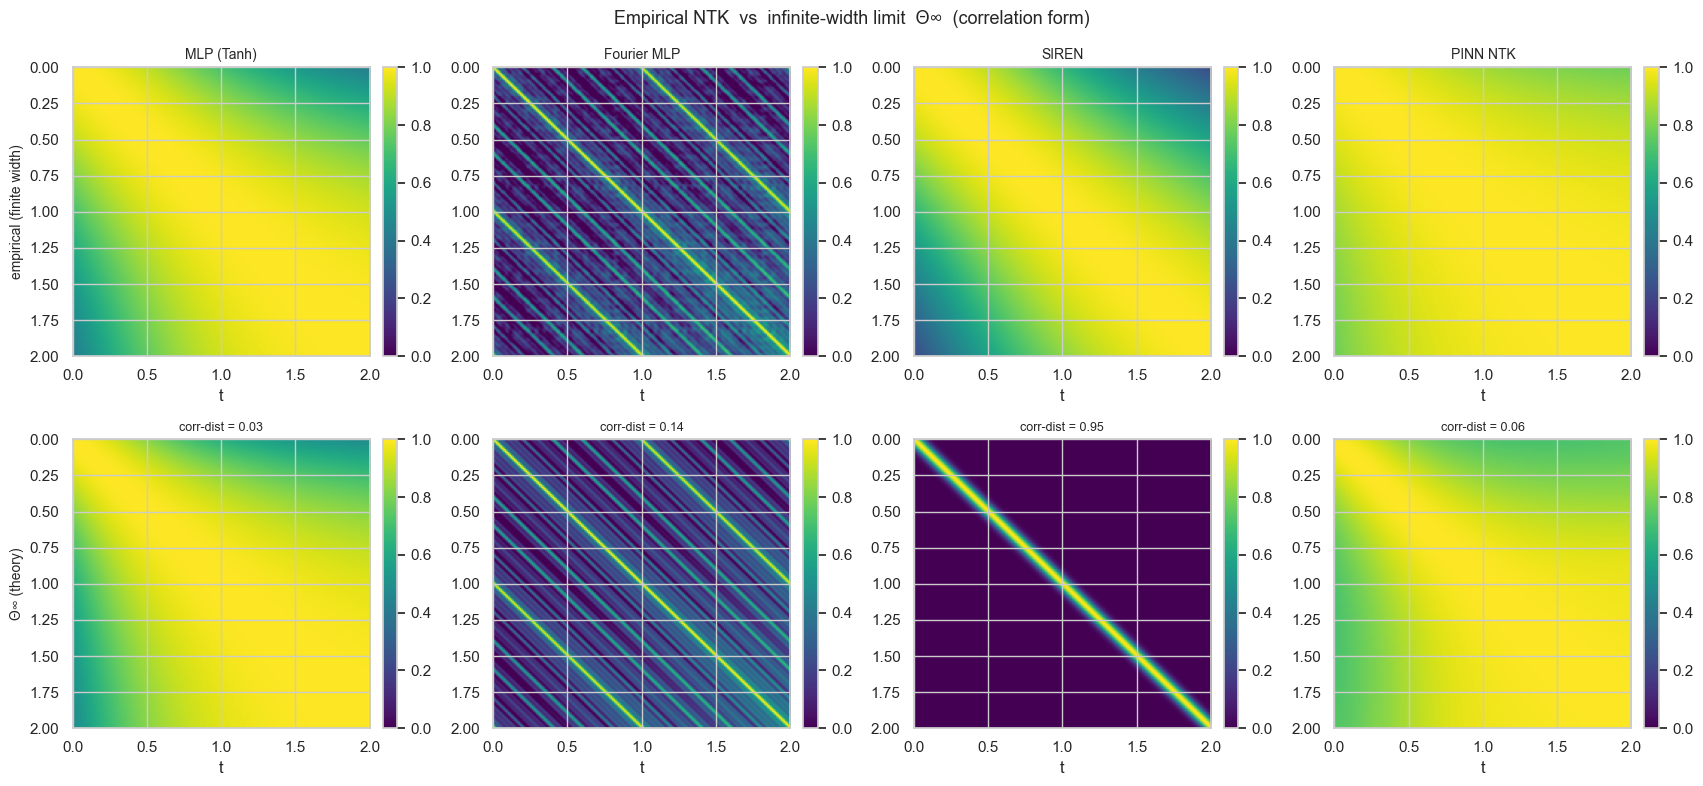

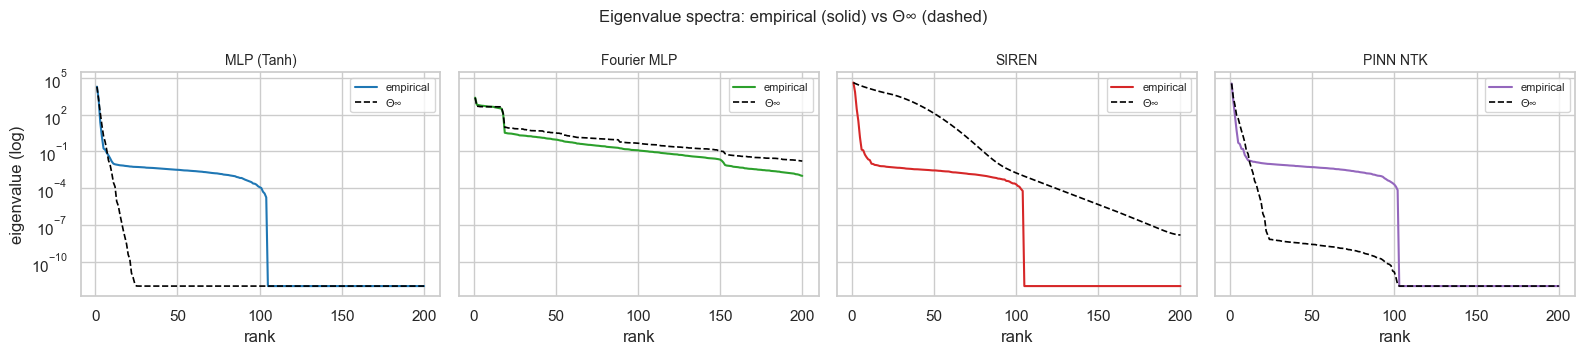

In [61]:
# ── Gallery: empirical NTK (top) vs infinite-width Θ_∞ (bottom), correlation form ─
names = list(INF_PAIRS.keys())
fig, axes = plt.subplots(2, len(names), figsize=(4.3 * len(names), 8))
fig.suptitle("Empirical NTK  vs  infinite-width limit  Θ∞  (correlation form)", fontsize=13)
axes[0, 0].set_ylabel("empirical (finite width)", fontsize=10)
axes[1, 0].set_ylabel("Θ∞ (theory)", fontsize=10)

for col, name in enumerate(names):
    K_emp, K_inf = INF_PAIRS[name]
    cd = (np.linalg.norm(_corr(K_inf)[sl, sl] - _corr(K_emp)[sl, sl])
          / np.linalg.norm(_corr(K_emp)[sl, sl]))
    for row, K in enumerate([K_emp, K_inf]):
        ax = axes[row, col]
        im = ax.imshow(_corr(K), cmap="viridis", aspect="auto",
                       extent=[t_eval[0], t_eval[-1], t_eval[-1], t_eval[0]], vmin=0, vmax=1)
        ax.set_xlabel("t")
        if row == 0:
            ax.set_title(name, fontsize=10)
        if row == 1:
            ax.set_title(f"corr-dist = {cd:.2f}", fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "infinite_width_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

# Spectrum overlay: empirical vs Θ∞ (rescaled to match λ_max) for each architecture
fig, axes = plt.subplots(1, len(names), figsize=(4.0 * len(names), 3.6), sharey=True)
fig.suptitle("Eigenvalue spectra: empirical (solid) vs Θ∞ (dashed)", fontsize=12)
idx = np.arange(1, len(t_eval) + 1)
for ax, name in zip(axes, names):
    K_emp, K_inf = INF_PAIRS[name]
    ve = np.linalg.eigvalsh(K_emp)[::-1]
    vi = np.linalg.eigvalsh(K_inf)[::-1]
    vi = vi * (ve[0] / vi[0])                       # align λ_max (scale is parametrisation-dependent)
    c = PALETTE.get(name, "steelblue")
    ax.semilogy(idx, np.clip(ve, 1e-12, None), color=c, lw=1.5, label="empirical")
    ax.semilogy(idx, np.clip(vi, 1e-12, None), color="black", lw=1.2, ls="--", label="Θ∞")
    ax.set_title(name, fontsize=10); ax.set_xlabel("rank")
    ax.legend(fontsize=8)
axes[0].set_ylabel("eigenvalue (log)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "infinite_width_spectra.png", dpi=150, bbox_inches="tight")
plt.show()